In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
data = pd.read_csv('data/shopify_sales_dataset_ml_eda.csv')
data.head()

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78
3,4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0,512.39,1537.17,1517.95
4,5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0,311.92,935.76,910.82


In [4]:
print(min(data['order_date']), max(data['order_date']))

2023-01-01 2025-06-18


In [5]:
sales_category = data.groupby('product_category')[['revenue', 'profit', 'discounted_price', 'shipping_cost']].sum()
sales_category['profit_margin'] = sales_category['profit']/sales_category['revenue']
sales_category.sort_values('revenue', ascending=False)

,revenue,profit,discounted_price,shipping_cost,profit_margin
product_category,,,,,
Electronics,8717301.49,8601068.01,2874477.23,116233.48,0.986666
Accessories,8609171.52,8492938.90,2844533.93,116232.62,0.986499
Home Decor,8545840.45,8428664.14,2837881.62,117176.31,0.986288
Beauty,8544881.95,8429076.60,2844109.52,115805.35,0.986447
Fashion,8445072.67,8327844.15,2799169.96,117228.52,0.986119
Sports,8434698.81,8319929.75,2827179.54,114769.06,0.986393
Footwear,8348968.69,8235108.55,2785860.92,113860.14,0.986362


In [6]:
orders = data.groupby('product_category')['order_id'].count()
sales_category['num_orders'] = sales_category.index.map(orders)
sales_category['avg_order_value'] = sales_category['revenue']/sales_category['num_orders']
sales_category['avg_profitability'] = sales_category['profit']/sales_category['num_orders']
sales_category

,revenue,profit,discounted_price,shipping_cost,profit_margin,num_orders,avg_order_value,avg_profitability
product_category,,,,,,,,
Accessories,8609171.52,8492938.90,2844533.93,116232.62,0.986499,8617,999.091507,985.602750
Beauty,8544881.95,8429076.60,2844109.52,115805.35,0.986447,8586,995.211035,981.723340
Electronics,8717301.49,8601068.01,2874477.23,116233.48,0.986666,8624,1010.818818,997.340910
Fashion,8445072.67,8327844.15,2799169.96,117228.52,0.986119,8594,982.670778,969.030038
Footwear,8348968.69,8235108.55,2785860.92,113860.14,0.986362,8457,987.225812,973.762392
Home Decor,8545840.45,8428664.14,2837881.62,117176.31,0.986288,8600,993.702378,980.077226
Sports,8434698.81,8319929.75,2827179.54,114769.06,0.986393,8522,989.755786,976.288401


In [7]:
# analysis on fashion
fashion = data[data['product_category']=='Fashion']

In [8]:
print(len(fashion['product_id'].unique()))
print(len(fashion['customer_id'].unique()))
print(len(fashion['order_id'].unique()))

4997
7761
8594


In [9]:
# Let's see if users are shopping cross categories
cross_cat_pur = data.groupby('customer_id')['product_category'].count().to_frame()
cross_cat_pur

,product_category
customer_id,
10000,1
10001,5
10002,2
10003,2
10004,1
...,...
49995,1
49996,3
49997,1


In [10]:
print(cross_cat_pur[cross_cat_pur['product_category']>1].size)
print(cross_cat_pur.size)

17832
31154


In [11]:
categories = data['product_category'].unique()

for cat in categories:
    cross_cat_pur[cat] = 0

purchases = data.groupby(['customer_id', 'product_category'])['order_id'].count().to_frame().reset_index()
purchases

,customer_id,product_category,order_id
0,10000,Accessories,1
1,10001,Fashion,1
2,10001,Footwear,1
3,10001,Home Decor,1
4,10001,Sports,2
...,...,...,...
54134,49996,Accessories,2
54135,49996,Fashion,1
54136,49997,Beauty,1
54137,49998,Sports,1


In [12]:
cross_pur = data.pivot_table(index='customer_id', columns='product_category', values='order_id', aggfunc='count', fill_value=0)
cross_pur

product_category,Accessories,Beauty,Electronics,Fashion,Footwear,Home Decor,Sports
customer_id,,,,,,,
10000,1,0,0,0,0,0,0
10001,0,0,0,1,1,1,2
10002,0,0,0,1,1,0,0
10003,0,0,0,1,0,1,0
10004,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...
49995,0,0,0,0,1,0,0
49996,2,0,0,1,0,0,0
49997,0,1,0,0,0,0,0


In [13]:
print(cross_pur[(cross_pur['Accessories']>0) & (cross_pur['Beauty']>0)].size)

10787


In [14]:
cross_pur2 = pd.DataFrame(index=categories, columns=categories)
for cat in categories:
    for cat2 in categories:
        cross_pur2.at[cat, cat2] = cross_pur[(cross_pur[cat]>0) & (cross_pur[cat2]>0)].size/cross_pur[cross_pur[cat]>0].size

cross_pur2

,Accessories,Sports,Electronics,Footwear,Beauty,Fashion,Home Decor
Accessories,1.0,0.192842,0.193486,0.193486,0.198378,0.189882,0.1931
Sports,0.194849,1.0,0.193418,0.185744,0.190947,0.19563,0.187435
Electronics,0.192989,0.190935,1.0,0.192604,0.193503,0.195172,0.192604
Footwear,0.196317,0.18652,0.195925,1.0,0.192529,0.188218,0.191745
Beauty,0.19956,0.190106,0.195157,0.190883,1.0,0.193603,0.190754
Fashion,0.190053,0.193789,0.195851,0.185672,0.19263,1.0,0.189795
Home Decor,0.193399,0.185792,0.193399,0.189273,0.189917,0.189917,1.0


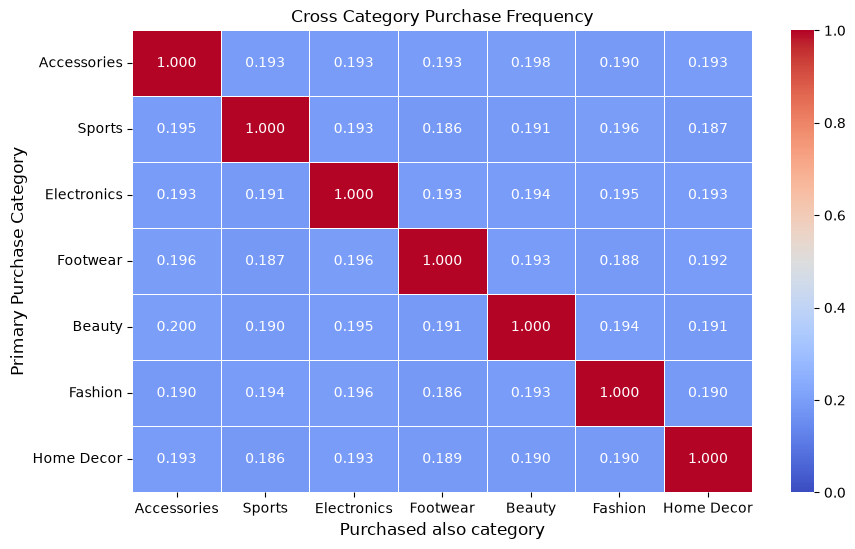

In [15]:
cross_pur2 = cross_pur2.astype(float)
plt.figure(figsize=(10,6))
sns.heatmap(cross_pur2, annot=True, cmap='coolwarm', fmt=".3f", vmin=0, vmax=1, linewidths=0.5, cbar={'label': 'Conditional Probability'})
plt.title('Cross Category Purchase Frequency')
plt.xlabel('Purchased also category', fontsize= 12)
plt.ylabel('Primary Purchase Category', fontsize=12)
plt.show()

In [16]:
# Beauty and Accessories are the two most frequently cross purchased categories 
acces_beauty = data[(data['product_category']=='Accessories')  | (data['product_category']=='Beauty')]
acces_beauty.describe()

,order_id,customer_id,product_id,product_price,discount_percent,quantity,shipping_cost,rating,is_returned,discounted_price,revenue,profit
count,17203.000000,17203.00000,17203.000000,17203.000000,17203.000000,17203.000000,17203.000000,17203.000000,17203.000000,17203.000000,17203.000000,17203.000000
mean,30021.147474,29995.82910,4508.823345,404.024624,18.176771,3.012091,13.488227,2.997262,0.148288,330.677408,997.154768,983.666541
std,17286.514484,11581.49938,2019.140827,229.644937,12.481796,1.418799,6.636235,1.148664,0.355396,196.346402,809.705473,809.714957
min,1.000000,10000.00000,1000.000000,5.030000,0.000000,1.000000,2.000000,1.000000,0.000000,3.250000,4.500000,-18.020000
25%,14985.000000,19867.00000,2752.500000,206.590000,10.000000,2.000000,7.810000,2.000000,0.000000,165.405000,354.700000,340.615000
50%,30073.000000,30007.00000,4511.000000,405.310000,20.000000,3.000000,13.480000,3.000000,0.000000,324.530000,761.480000,746.980000
75%,45046.000000,40089.00000,6259.000000,602.640000,30.000000,4.000000,19.240000,4.000000,0.000000,482.480000,1469.085000,1456.955000
max,60000.000000,49997.00000,7999.000000,799.970000,40.000000,5.000000,25.000000,5.000000,1.000000,799.700000,3983.150000,3974.610000


In [17]:
acces_beauty

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
5,6,2023-03-13,29596,2796,Beauty,444.14,0,5,UAE,Social Media,Apple Pay,20.29,2.6,0,444.14,2220.70,2200.41
6,7,2024-12-01,11896,6012,Accessories,244.18,15,1,Canada,Social Media,Debit Card,23.91,1.4,0,207.55,207.55,183.64
7,8,2023-01-21,43857,4248,Beauty,457.16,25,1,USA,Email,Apple Pay,4.17,3.0,0,342.87,342.87,338.70
15,16,2024-01-08,22384,7035,Accessories,719.96,10,1,Canada,Social Media,Credit Card,20.44,3.6,1,647.96,647.96,627.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59992,59993,2024-10-27,32236,2170,Accessories,636.25,15,5,UK,Email,Debit Card,23.87,1.4,0,540.81,2704.05,2680.18
59994,59995,2025-05-17,49820,1441,Accessories,348.76,30,2,India,Paid Ads,Debit Card,24.15,2.0,0,244.13,488.26,464.11
59995,59996,2025-04-15,11769,6227,Beauty,434.55,5,4,India,Direct,PayPal,5.12,3.9,0,412.82,1651.28,1646.16
59998,59999,2023-09-10,18973,7151,Beauty,365.99,40,3,UK,Paid Ads,Cash on Delivery,9.44,2.2,0,219.59,658.77,649.33


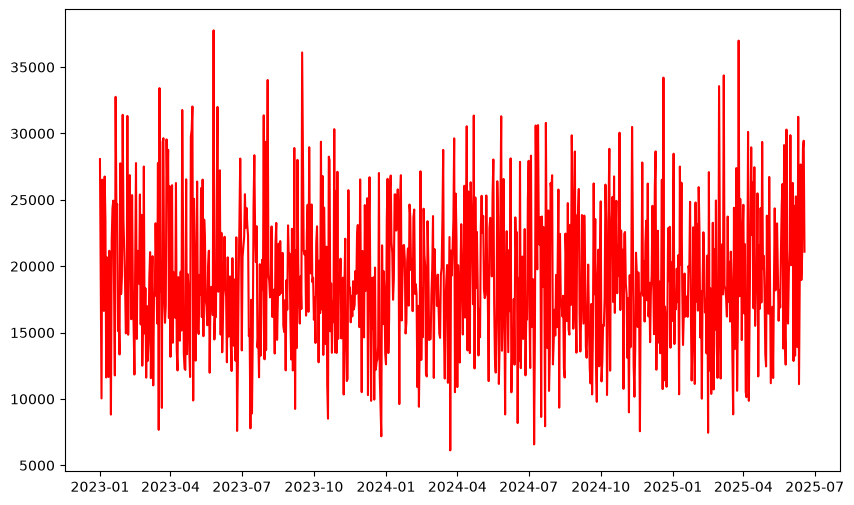

In [18]:
historical_sales = acces_beauty.groupby('order_date')['revenue'].sum().to_frame().reset_index()
historical_sales['order_date'] = pd.to_datetime(historical_sales['order_date'])
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(historical_sales['order_date'], historical_sales['revenue'], color='red')
plt.show()

In [19]:
# Preparing data for market segmentation based on behavior of users

df = acces_beauty[['order_date']]
df['order_date'] = pd.to_datetime(df['order_date'])
# max date
max_date = df['order_date'].max() + pd.Timedelta(days=1)
# data aggregation 
customer_data = acces_beauty.groupby('customer_id').agg({
    'order_date': lambda x: (max_date - pd.to_datetime(x).max()).days,
    'order_id': 'nunique',
    'revenue': 'sum',
    'is_returned': 'mean'
}).reset_index()

customer_data.columns = ['customer_id', 'recency', 'frequency', 'monetary', 'return_rate']

In [20]:
# fixing skewness in the data 
features = ['recency', 'frequency', 'monetary']
df_log = customer_data[features].copy()

for col in features:
    df_log[col] = np.log1p(df_log[col])

In [21]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)
df_scaled = pd.DataFrame(df_scaled, columns=features)

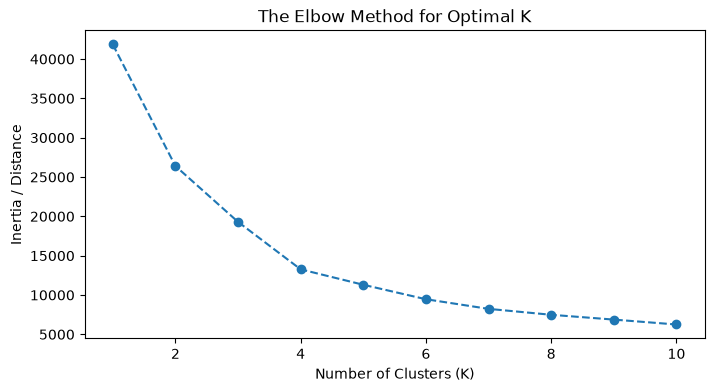

In [22]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia / Distance')
plt.title('The Elbow Method for Optimal K')
plt.show()

In [23]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_scaled)

customer_data['cluster'] = cluster_labels

In [24]:
analysis = customer_data.groupby('cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'segment_size'})

print(analysis)

            recency  frequency     monetary  segment_size
cluster                                                  
0        523.190239   1.000000  1388.252692          6229
1        300.698964   2.151257  2152.286250          2704
2        492.442179   1.004565   232.230469          3286
3         61.901156   1.072832  1111.986191          1730


In [29]:
# Visualizing the chart 
segment_counts = analysis['segment_size']
segment_names = {
    0: 'Lost/One Off Buyers',
    1: 'Loyal',
    2: 'Ad Hoc',
    3: 'New Buyers'
}

segment_counts.index = segment_counts.index.map(segment_names)
segment_counts


cluster
Lost/One Off Buyers    6229
Loyal                  2704
Ad Hoc                 3286
New Buyers             1730
Name: segment_size, dtype: int64

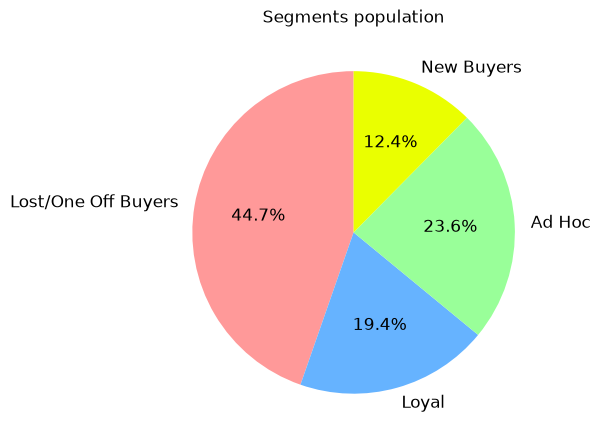

In [35]:
plt.figure(figsize=(6,6))
segment_counts.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999','#66b3ff','#99ff99', '#eaff00'],
    textprops={'fontsize': 12}
)

plt.title("Segments population")
plt.ylabel('')
plt.tight_layout()
plt.show()